
# Quickstart — `opciones.volatilidad`

Cuatro funciones para estimar volatilidad implícita, más una para
graficarla contra el strike:

- `estimacion_sigma_Newton` — Newton-Raphson (rápido, usa Vega).
- `estimacion_sigma_tangente` — secante (rápido, no necesita Vega).
- `estimacion_sigma_biseccion` — bisección (más lento, pero solo necesita
  un rango que encierre la solución).
- `sonrisa_volatilidad` — aplica Newton a varios strikes y grafica la
  sonrisa resultante.

Los tres métodos de estimación deben converger, para el mismo precio de
mercado, prácticamente al mismo sigma — es una buena forma de verificar
que todo está bien calibrado.

> Nota: `estimacion_sigma_Newton` y `estimacion_sigma_biseccion` imprimen
> el progreso de cada iteración (`iter=...`); aquí se silencia con
> `contextlib.redirect_stdout` para quedarnos solo con el resultado.


In [1]:

from modelado_financiero.volatilidad import (
    sonrisa_volatilidad,
    estimacion_sigma_Newton,
    estimacion_sigma_tangente,
    estimacion_sigma_biseccion
)




## `estimacion_sigma_Newton`

Precio de mercado observado de \$3.50 para una call con
$S_0=100$, $K=105$, $T=0.5$, $r=2\%$.


In [9]:

S0, K, T, r, precio_mercado = 100, 105, 0.5, 0.02, 3.50

estimacion_sigma_Newton( S0, K, T, r, precio_mercado, tipo='call', error=1e-4)


iter=1, sigma_actual=0.1821523773, precio=3.4941343298, error=5.8656701501e-03
iter=2, sigma_actual=0.1823662203, precio=3.5000002976, error=2.9764351694e-07


np.float64(0.18236622028055588)


## `estimacion_sigma_tangente` (secante)

Mismos datos — no imprime iteraciones, así que se llama directo.


In [4]:

estimacion_sigma_tangente(S0, K, T, r, precio_mercado, tipo='call', error=1e-8)


iter=1, sigma_actual=0.1823653856, error=2.2598787453e-05
iter=2, sigma_actual=0.1823662063, error=8.6952248068e-08
iter=3, sigma_actual=0.1823662094, error=2.8421709430e-14


np.float64(0.18236620943055432)


## `estimacion_sigma_biseccion`

Requiere un rango inicial `[sigma_low, sigma_high]` que encierre la
solución (a diferencia de Newton/secante, no calcula una semilla sola).


In [10]:

estimacion_sigma_biseccion(S0, K, T, r, precio_mercado, 0.05, 0.60, tipo='call', error=1e-2)


iter=1, sigma_actual=0.3250000000, precio_modelo=7.4832171799, error=3.9832171799e+00
iter=2, sigma_actual=0.1875000000, precio_modelo=3.6409993746, error=1.4099937456e-01
iter=3, sigma_actual=0.1187500000, precio_modelo=1.7952956924, error=1.7047043076e+00
iter=4, sigma_actual=0.1531250000, precio_modelo=2.7044769919, error=7.9552300814e-01
iter=5, sigma_actual=0.1703125000, precio_modelo=3.1703479603, error=3.2965203969e-01
iter=6, sigma_actual=0.1789062500, precio_modelo=3.4051636838, error=9.4836316164e-02
iter=7, sigma_actual=0.1832031250, precio_modelo=3.5229632768, error=2.2963276841e-02
iter=8, sigma_actual=0.1810546875, precio_modelo=3.4640328267, error=3.5967173318e-02
iter=9, sigma_actual=0.1821289062, precio_modelo=3.4934905285, error=6.5094715276e-03


0.18212890625


## `sonrisa_volatilidad`

Recibe un arreglo de strikes y sus precios de mercado, calcula la
volatilidad implícita de cada uno (con Newton) y **grafica la sonrisa
resultante** — esta gráfica sí es parte de la librería (la genera la
propia función), no algo agregado por fuera.


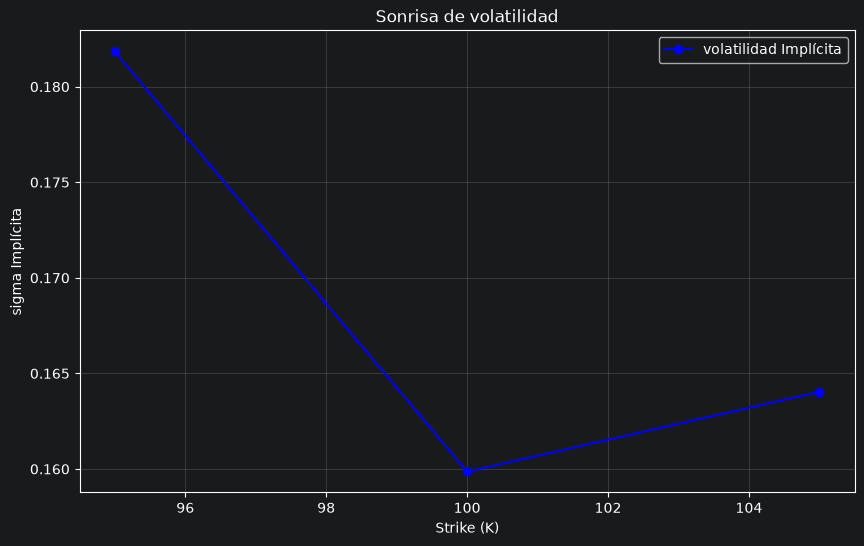

array([0.18184052, 0.15986819, 0.1640512 ])

In [11]:

strikes = [95, 100, 105]
precios = [8.50, 5.00, 3.00]

sonrisa_volatilidad(S0, r, T, strikes, precios, tipo='call')
